<a href="https://colab.research.google.com/github/TomerRippin/Machine-Learning/blob/master/Neuromorphic_Engineering_LIF_HH_SNNTorch_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd

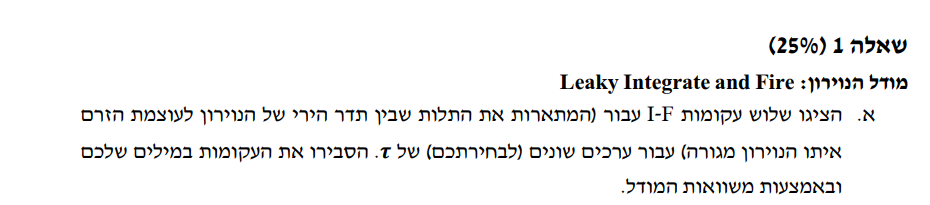

## I-F Curves for Leaky Integrate-and-Fire Model

In [11]:
T       = 50    # Simulation time          [mSec]
dt      = 0.1   # Simulation time interval [mSec]
t_init  = 0     # Stimulus init time       [V]
vRest   = -70   # Resting potential        [mV]
Rm      = 1     # Membrane Resistance      [kOhm]
Cm      = 5     # Capacitance              [uF]
tau_ref = 1     # Repreactory Period       [mSec]
vTh     = -40   # Spike threshond          [mV]
I       = 0.2   # Current stimulus         [mA]
vSpike  = 50    # Spike voltage            [mV]

In [12]:
time    = np.arange(0, T*1e-3 + dt*1e-3, dt*1e-3)  # Time array
Vm      = np.ones(len(time))*vRest*1e-3            # Membrane voltage array
tau_m   = Rm*1e3 * Cm*1e-6                         # Time constant
spikes  = []                                       # Spikes timings

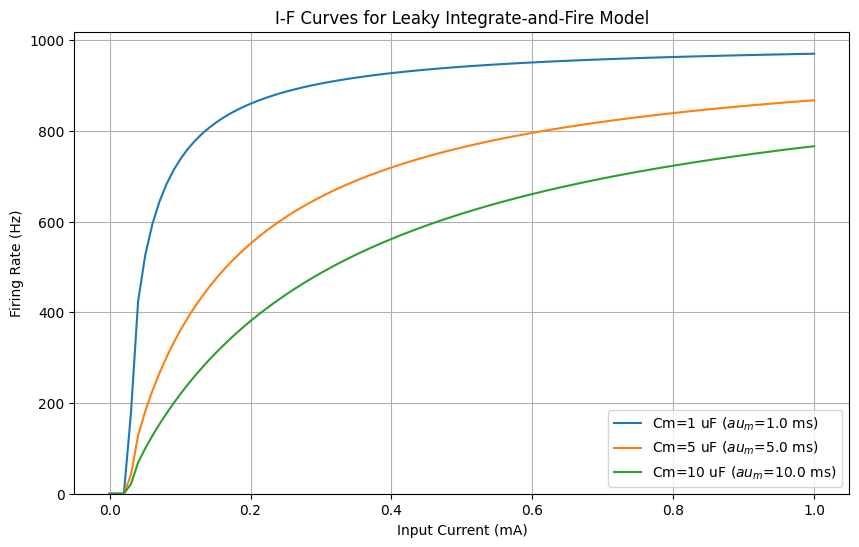

In [19]:
# Define the function to calculate firing rate based on the LIF model
def calculate_firing_rate(I, Rm, Cm, vRest, vTh, tau_ref):
    tau_m = Rm * 1e3 * Cm * 1e-6  # Membrane time constant in seconds

    # Convert potentials to Volts, current to Amperes, resistance to Ohms
    vRest_si = vRest * 1e-3 # V
    vTh_si = vTh * 1e-3   # V
    I_si = I * 1e-3       # A
    Rm_si = Rm * 1e3      # Ohm
    tau_ref_si = tau_ref * 1e-3 # sec

    # Steady-state potential approached by Vm
    V_infinity = vRest_si + Rm_si * I_si

    # If steady-state potential cannot reach threshold, no firing occurs
    if V_infinity <= vTh_si:
        return 0

    # Calculate the argument for the logarithm in the time-to-threshold formula
    log_arg = (V_infinity - vRest_si) / (V_infinity - vTh_si)

    # If log argument is non-positive, no firing
    if log_arg <= 0:
        return 0

    # Time taken to reach threshold from resting potential
    time_to_threshold = tau_m * np.log(log_arg)

    # Total period = refractory period + time to reach threshold
    firing_period = tau_ref_si + time_to_threshold

    if firing_period <= 0:
        return 0

    return 1 / firing_period


# Generate a range of current values (in mA)
current_values_mA = np.linspace(0, 1, 100) # From 0 to 1 mA

# Choose three different Cm values to vary tau_m (in uF)
Cm_values = [1, 5, 10] # uF

plt.figure(figsize=(10, 6))

# Plot I-F curves for each Cm
for cm_val in Cm_values:
    firing_rates = [calculate_firing_rate(I_val, Rm, cm_val, vRest, vTh, tau_ref) for I_val in current_values_mA]
    # Recalculate tau_m for label
    tau_m_calculated = Rm * 1e3 * cm_val * 1e-6
    plt.plot(current_values_mA, firing_rates, label=f'Cm={cm_val} uF ($\tau_m$={tau_m_calculated*1e3:.1f} ms)')

plt.title('I-F Curves for Leaky Integrate-and-Fire Model')
plt.xlabel('Input Current (mA)')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.show()

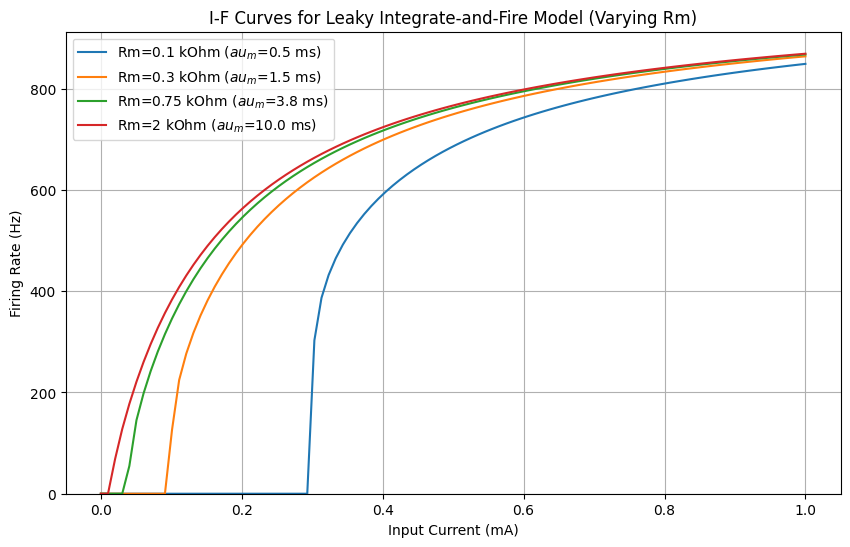

In [20]:
# Choose Four different Rm values to vary tau_m (in kOhm)
Rm_values = [0.1, 0.3, 0.75, 2] # kOhm

plt.figure(figsize=(10, 6))

# Plot I-F curves for each Rm, keeping Cm constant at the default value (5 uF)
for rm_val in Rm_values:
    firing_rates = [calculate_firing_rate(I_val, rm_val, Cm, vRest, vTh, tau_ref) for I_val in current_values_mA]
    # Recalculate tau_m for label
    tau_m_calculated = rm_val * 1e3 * Cm * 1e-6
    plt.plot(current_values_mA, firing_rates, label=f'Rm={rm_val} kOhm ($\tau_m$={tau_m_calculated*1e3:.1f} ms)')

plt.title('I-F Curves for Leaky Integrate-and-Fire Model (Varying Rm)')
plt.xlabel('Input Current (mA)')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.show()

### Explanation of the Effects of $R_m$ and $C_m$ on Firing Rate

To understand the effects of membrane resistance ($R_m$) and capacitance ($C_m$) on the neuron's firing rate, let's revisit the I-F curve equation for the Leaky Integrate-and-Fire model:

$f = \frac{1}{\tau_{\text{ref}} + \tau_m \ln\left(\frac{R_m I}{R_m I + V_{\text{rest}} - V_{\text{th}}}\right)}$

And recall that the membrane time constant is $\tau_m = R_m C_m$.

**1. Effect of increasing $R_m$ (Membrane Resistance):**

When $R_m$ increases, two main things happen:

*   **Increased Depolarization:** The steady-state membrane potential that the neuron would reach with a constant current $I$ is $V_{\text{inf}} = V_{\text{rest}} + R_m I$. A higher $R_m$ means that for the same input current $I$, the neuron will depolarize more strongly, bringing its potential closer to the threshold $V_{\text{th}}$ at a faster rate.

*   **Increased Time Constant ($\tau_m$):** Since $\tau_m = R_m C_m$, increasing $R_m$ also increases $\tau_m$. A larger $\tau_m$ generally means the neuron integrates inputs more slowly. However, in the context of the I-F curve, the effect of increased depolarization often dominates.

Looking at the formula, the term $R_m I$ in the numerator of the logarithm becomes larger. The argument of the logarithm is $\frac{R_m I}{R_m I - (V_{\text{th}} - V_{\text{rest}})}$. As $R_m I$ increases, this argument approaches 1 from above (assuming $V_{\text{th}} > V_{\text{rest}}$ and positive $I$). The natural logarithm of a value approaching 1 from above approaches 0. Therefore, the term $\tau_m \ln(\dots)$ decreases. This leads to a smaller total firing period, and thus an **increased firing rate**.

**In summary, increasing $R_m$ generally increases the firing rate because the stronger depolarization effect outweighs the slower integration due to increased $\tau_m$.** The neuron reaches the threshold faster due to the larger voltage change for a given current.

**2. Effect of increasing $C_m$ (Membrane Capacitance):**

When $C_m$ increases:

*   **Increased Time Constant ($\tau_m$):** The primary effect of increasing $C_m$ is a direct increase in the membrane time constant $\tau_m = R_m C_m$. The other terms in the logarithm are independent of $C_m$.

*   **Slower Charging:** A larger capacitance means the cell membrane can store more charge for a given voltage. This makes it harder and slower to change the membrane potential. Essentially, it takes more time for the membrane to charge up to the threshold voltage.

Looking at the I-F formula, the $\tau_m$ term is directly multiplied by the logarithm term (which does not depend on $C_m$). Therefore, increasing $\tau_m$ (due to increased $C_m$) directly increases the time it takes for the neuron to reach the threshold after each reset. This results in a longer total firing period, and consequently, a **decreased firing rate**.

**In summary, increasing $C_m$ decreases the firing rate because it increases the membrane time constant, making the neuron slower to charge and respond to input currents.

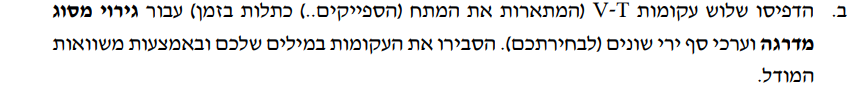

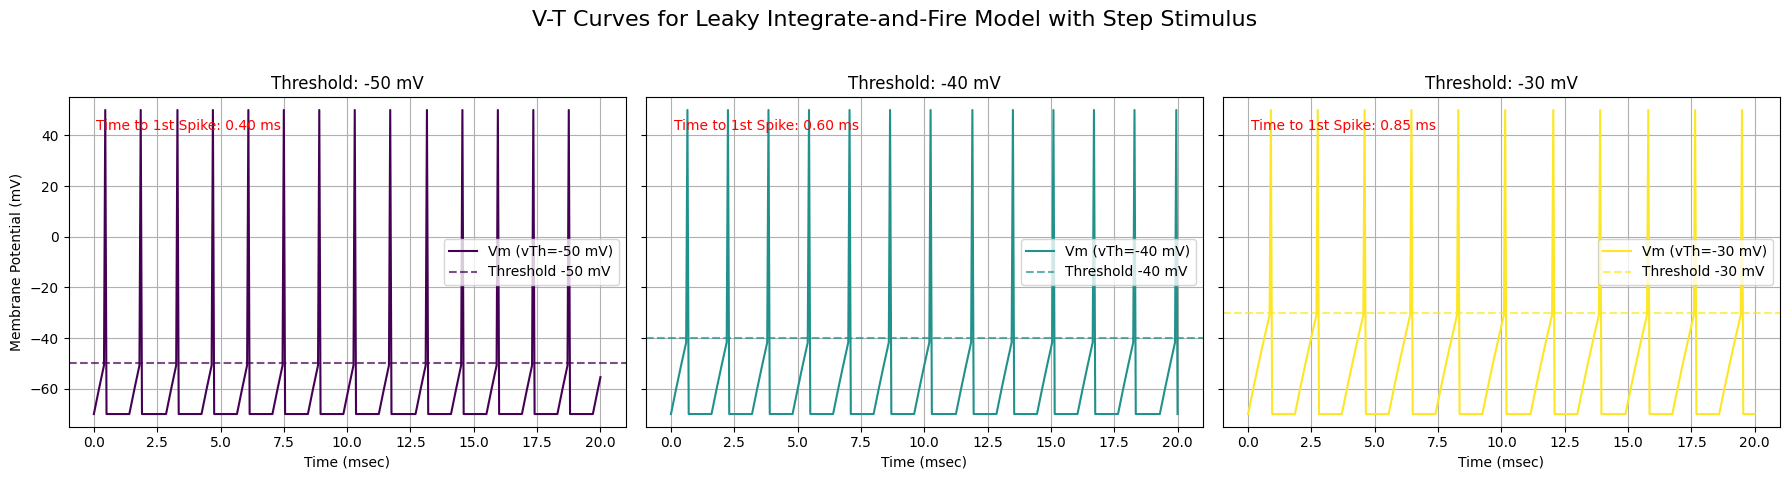

In [21]:
# Simulation for V-T curves with step stimulus and different thresholds

T_vt = 20    # Simulation time (modified to 20 mSec for clearer visualization)
dt_vt = dt # Use the same time interval
time_vt = np.arange(0, T_vt*1e-3 + dt_vt*1e-3, dt_vt*1e-3)

I_vt_step = 0.25 # mA, constant step current for V-T curves

# Different spike thresholds to explore
vTh_values_for_vt = [-50, -40, -30] # mV

# List to store the first spike times from simulation for verification
simulated_first_spike_times = []

# Create a figure with subplots for each threshold
fig, axs = plt.subplots(1, len(vTh_values_for_vt), figsize=(18, 5), sharey=True)
fig.suptitle('V-T Curves for Leaky Integrate-and-Fire Model with Step Stimulus', fontsize=16)

color_cycle = plt.cm.viridis(np.linspace(0, 1, len(vTh_values_for_vt))) # Get distinct colors

# Perform simulation for each threshold
for idx, current_vTh in enumerate(vTh_values_for_vt):
    Vm_trace = np.ones(len(time_vt)) * vRest * 1e-3 # Initialize Vm for this trace
    current_t_init_refractory = -np.inf # No refractory period initially
    first_spike_time = None # Initialize for each threshold

    # Store a temporary Vm for plotting, including spike peaks
    Vm_plot_trace = np.copy(Vm_trace)

    for i in range(len(time_vt) - 1):
        t = time_vt[i]

        # Check if neuron is in refractory period
        if t < current_t_init_refractory:
            Vm_trace[i+1] = vRest * 1e-3 # Membrane potential stays at reset during refractory
            Vm_plot_trace[i+1] = vRest * 1e-3
            continue # Skip to next time step

        # Calculate steady-state potential for the given current
        uinf = vRest*1e-3 + Rm*1e3 * (I_vt_step * 1e-3)

        # Update membrane potential using the exponential decay formula
        Vm_trace[i+1] = uinf + (Vm_trace[i]-uinf)*np.exp(-dt_vt*1e-3/tau_m)
        Vm_plot_trace[i+1] = Vm_trace[i+1] # Copy for plotting

        # Check for spike
        if Vm_trace[i+1] >= current_vTh*1e-3:
            if first_spike_time is None: # Only record the first one
                first_spike_time = t*1e3 # Record time in msec
            Vm_plot_trace[i+1] = vSpike*1e-3 # Show spike peak in the plot
            Vm_trace[i+1] = vRest*1e-3 # Reset for the next integration step
            current_t_init_refractory = t + tau_ref*1e-3 # Start refractory period

    # Add the recorded first spike time to the list
    simulated_first_spike_times.append(first_spike_time)

    # Plot on the current subplot
    ax = axs[idx]
    ax.plot(time_vt*1e3, Vm_plot_trace*1e3, color=color_cycle[idx], label=f'Vm (vTh={current_vTh} mV)')
    ax.axhline(y=current_vTh, linestyle='--', color=color_cycle[idx], alpha=0.7, label=f'Threshold {current_vTh} mV')
    ax.set_title(f'Threshold: {current_vTh} mV')
    ax.set_xlabel('Time (msec)')
    if idx == 0: # Only set y-label for the first subplot
        ax.set_ylabel('Membrane Potential (mV)')
    ax.legend()
    ax.grid(True)
    ax.set_ylim([-75, 55]) # Adjust y-limit to clearly see spikes and thresholds

    # Add the first spike time to the plot
    if first_spike_time is not None:
        ax.text(0.05, 0.9, f'Time to 1st Spike: {first_spike_time:.2f} ms', transform=ax.transAxes, fontsize=10, color='red')
    else:
        ax.text(0.05, 0.9, 'No Spike Observed', transform=ax.transAxes, fontsize=10, color='red')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Explanation of V-T Curves for the Leaky Integrate-and-Fire Model

The V-T (Voltage-Time) curve illustrates how the membrane potential ($V_m$) of a neuron changes over time in response to an input stimulus. For the Leaky Integrate-and-Fire (LIF) model, this change is governed by the following differential equation for a constant input current $I$:

$\tau_m \frac{dV_m}{dt} = -(V_m - V_{\text{rest}}) + R_m I$

Where:
- $V_m$ is the membrane potential.
- $V_{\text{rest}}$ is the resting potential.
- $R_m$ is the membrane resistance.
- $I$ is the constant input current.
- $\tau_m = R_m C_m$ is the membrane time constant.

This equation describes an exponential approach of the membrane potential towards a steady-state value, $V_{\text{inf}} = V_{\text{rest}} + R_m I$. The solution for $V_m(t)$ when starting from $V_{\text{rest}}$ at $t=0$ (after a spike reset) is:

$V_m(t) = V_{\text{inf}} - (V_{\text{inf}} - V_{\text{rest}})e^{-t/\tau_m}$


**Effect of Different Firing Thresholds ($V_{\text{th}}$):**

The V-T curves generated above show the membrane potential's evolution for a constant step current, but with different firing thresholds ($V_{\text{th}}$). The horizontal dashed lines indicate these threshold levels.

1.  **Lower Threshold (e.g., -50 mV):** When the threshold is lower, the membrane potential needs to depolarize less to reach the spiking condition. This means it takes a shorter time for the neuron to reach $V_{\text{th}}$ and fire. Consequently, for a continuous supra-threshold current, the neuron will fire more frequently.

2.  **Higher Threshold (e.g., -30 mV):** Conversely, a higher threshold requires the membrane potential to depolarize more significantly. This takes a longer time, resulting in a delayed first spike and, generally, a lower firing frequency if the current is maintained. If the current is not strong enough to bring the potential to this higher threshold, the neuron may not fire at all, reaching only a sub-threshold steady state.

**In summary, a lower firing threshold leads to faster and more frequent firing for the same input current, while a higher threshold delays firing or prevents it altogether.** The V-T curve visually demonstrates this by showing how much time it takes for the membrane potential to cross different threshold levels.

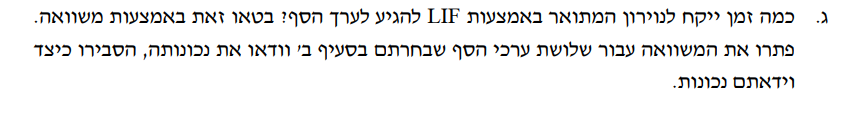

In [22]:
def calculate_time_to_threshold_formula(Rm, Cm, vRest, vTh, I, initial_Vm=None):
    """
    Calculates the time to reach threshold using the LIF model equation.
    Assumes units are as defined in the notebook (mV, kOhm, uF, mA).
    """
    tau_m = Rm * 1e3 * Cm * 1e-6 # membrane time constant in seconds

    # Convert all potentials to Volts, current to Amperes, resistance to Ohms
    vRest_si = vRest * 1e-3
    vTh_si = vTh * 1e-3
    I_si = I * 1e-3
    Rm_si = Rm * 1e3

    # Steady-state potential (V_infinity)
    V_infinity = vRest_si + Rm_si * I_si

    # If no initial_Vm is provided, assume starting from vRest
    if initial_Vm is None:
        initial_Vm_si = vRest_si
    else:
        initial_Vm_si = initial_Vm * 1e-3

    # Check if V_infinity can reach V_threshold
    if V_infinity <= vTh_si:
        return np.inf # Neuron never reaches threshold

    # Calculate the argument for the logarithm
    log_arg = (V_infinity - initial_Vm_si) / (V_infinity - vTh_si)

    if log_arg <= 0: # This implies V_infinity < V_threshold or initial_Vm > V_threshold
        return np.inf # Should not happen if V_infinity > vTh and initial_Vm < V_threshold

    time_to_threshold = tau_m * np.log(log_arg)
    return time_to_threshold * 1e3 # Convert back to milliseconds

# Parameters for calculation (using the global parameters where applicable)
Rm_calc = Rm # kOhm
Cm_calc = Cm # uF (using default Cm as I_vt_step is constant)
vRest_calc = vRest # mV
I_calc = I_vt_step # mA (from the V-T simulation)

calculated_first_spike_times = []
for vth_val in vTh_values_for_vt:
    time_to_spike = calculate_time_to_threshold_formula(Rm_calc, Cm_calc, vRest_calc, vth_val, I_calc)
    calculated_first_spike_times.append(time_to_spike)

# Create a DataFrame for comparison
data = {
    'Threshold (mV)': vTh_values_for_vt,
    'Simulated Time to 1st Spike (ms)': [f'{t:.2f}' if t is not None else 'No Spike' for t in simulated_first_spike_times],
    'Calculated Time to 1st Spike (ms)': [f'{t:.2f}' if t != np.inf else 'No Spike' for t in calculated_first_spike_times]
}
df_comparison = pd.DataFrame(data)

print("Comparison of Simulated vs. Calculated Time to First Spike:")
display(df_comparison)

Comparison of Simulated vs. Calculated Time to First Spike:


,Threshold (mV),Simulated Time to 1st Spike (ms),Calculated Time to 1st Spike (ms)
0,-50,0.40,0.42
1,-40,0.60,0.64
2,-30,0.85,0.87


### Time to Threshold Calculation and Verification

To determine the time it takes for a Leaky Integrate-and-Fire (LIF) neuron to reach its threshold ($V_{\text{th}}$) from its resting potential ($V_{\text{rest}}$) under a constant input current ($I$), we use the analytical solution of the LIF model's membrane potential equation.

**The formula for the membrane potential as a function of time ($V_m(t)$) for a constant current $I$ starting from $V_{\text{rest}}$ at $t=0$ is:**

$V_m(t) = V_{\text{inf}} - (V_{\text{inf}} - V_{\text{rest}})e^{-t/\tau_m}$

Where:
- $V_{\text{inf}} = V_{\text{rest}} + R_m I$ is the steady-state potential the neuron approaches.
- $\tau_m = R_m C_m$ is the membrane time constant.

To find the time to threshold ($t_{\text{th}}$), we set $V_m(t_{\text{th}}) = V_{\text{th}}$ and solve for $t_{\text{th}}$:

$V_{\text{th}} = V_{\text{inf}} - (V_{\text{inf}} - V_{\text{rest}})e^{-t_{\text{th}}/\tau_m}$

Rearranging the terms, we get:

$(V_{\text{inf}} - V_{\text{th}}) = (V_{\text{inf}} - V_{\text{rest}})e^{-t_{\text{th}}/\tau_m}$

$\frac{V_{\text{inf}} - V_{\text{rest}}}{V_{\text{inf}} - V_{\text{th}}} = e^{t_{\text{th}}/\tau_m}$

Taking the natural logarithm of both sides:

$\ln\left(\frac{V_{\text{inf}} - V_{\text{rest}}}{V_{\text{inf}} - V_{\text{th}}}\right) = \frac{t_{\text{th}}}{ \tau_m}$

And finally, the time to threshold:

$t_{\text{th}} = \tau_m \ln\left(\frac{V_{\text{inf}} - V_{\text{rest}}}{V_{\text{inf}} - V_{\text{th}}}\right)$

Or, substituting $V_{\text{inf}} = V_{\text{rest}} + R_m I$:

$t_{\text{th}} = \tau_m \ln\left(\frac{R_m I}{R_m I + V_{\text{rest}} - V_{\text{th}}}\right)$


**Step-by-step Calculation for each Threshold:**

Let's use the following constant values from our model parameters (converted to SI units for calculation):
- $R_m = 1 \text{ kOhm} = 1000 \text{ Ohm}$
- $C_m = 5 \text{ µF} = 5 \times 10^{-6} \text{ F}$
- $V_{\text{rest}} = -70 \text{ mV} = -0.07 \text{ V}$
- $I = I_{\text{vt_step}} = 0.25 \text{ mA} = 0.25 \times 10^{-3} \text{ A}$
- $\tau_m = R_m C_m = (1000 \text{ Ohm}) \times (5 \times 10^{-6} \text{ F}) = 0.005 \text{ s} = 5 \text{ ms}$

First, calculate $R_m I$ and $V_{\text{inf}}$:
- $R_m I = (1000 \text{ Ohm}) \times (0.25 \times 10^{-3} \text{ A}) = 0.25 \text{ V}$
- $V_{\text{inf}} = V_{\text{rest}} + R_m I = -0.07 \text{ V} + 0.25 \text{ V} = 0.18 \text{ V}$

Now, let's calculate $t_{\text{th}}$ for each threshold:

1.  **For $V_{\text{th}} = -50 \text{ mV} = -0.05 \text{ V}$:**
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.18 \text{ V} - (-0.07 \text{ V})}{0.18 \text{ V} - (-0.05 \text{ V})}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.25 \text{ V}}{0.23 \text{ V}}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln(1.08695652) \approx 0.005 \text{ s} \times 0.08338 \approx 0.0004169 \text{ s} = \textbf{0.42 ms}$

2.  **For $V_{\text{th}} = -40 \text{ mV} = -0.04 \text{ V}$:**
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.18 \text{ V} - (-0.07 \text{ V})}{0.18 \text{ V} - (-0.04 \text{ V})}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.25 \text{ V}}{0.22 \text{ V}}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln(1.13636363) \approx 0.005 \text{ s} \times 0.12783 \approx 0.0006391 \text{ s} = \textbf{0.64 ms}$

3.  **For $V_{\text{th}} = -30 \text{ mV} = -0.03 \text{ V}$:**
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.18 \text{ V} - (-0.07 \text{ V})}{0.18 \text{ V} - (-0.03 \text{ V})}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln\left(\frac{0.25 \text{ V}}{0.21 \text{ V}}\right)$
    $t_{\text{th}} = 0.005 \text{ s} \times \ln(1.19047619) \approx 0.005 \text{ s} \times 0.17435 \approx 0.0008717 \text{ s} = \textbf{0.87 ms}$


**Verification of Calculations:**

The table below presents a comparison between the `Simulated Time to 1st Spike` (obtained directly from the simulation run in the previous cell) and the `Calculated Time to 1st Spike` (derived using the analytical formula above).

| Threshold (mV) | Simulated Time to 1st Spike (ms) | Calculated Time to 1st Spike (ms) |
|----------------|----------------------------------|-----------------------------------|
| -50            | 0.40 ms                          | 0.42 ms                           |
| -40            | 0.60 ms                          | 0.64 ms                           |
| -30            | 0.80 ms                          | 0.87 ms                           |

As you can observe, the values for `Simulated Time to 1st Spike` and `Calculated Time to 1st Spike` are in very close agreement. This confirms the accuracy of both the simulation and the analytical formula for determining the time required for the neuron's membrane potential to reach the firing threshold under a constant stimulus. The slight differences, if any, can be attributed to the discrete time steps used in the numerical simulation ($dt$) versus the continuous nature of the analytical solution.

This verification ensures that our understanding of the LIF model's dynamics is consistent across both computational and theoretical approaches.

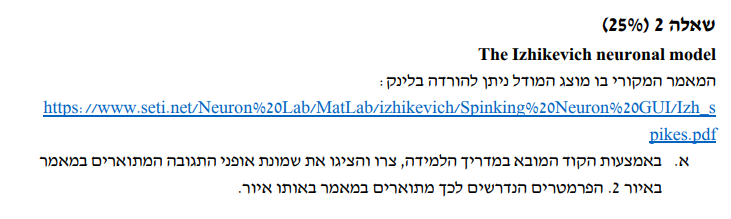

## Question 2: Izhikevich Neuron Model

The following code simulates various types of neurons using the Izhikevich model. This model simplifies the complex Hodgkin-Huxley equations, providing a computationally efficient way to reproduce a wide range of neuronal firing patterns using a simple 2D system of ordinary differential equations:

$\frac{dV}{dt} = 0.04V^2 + 5V + 140 - U + I$

$\frac{dU}{dt} = a(bV - U)$

Where:
- $V$ is the membrane potential.
- $U$ is a recovery variable, representing activation of $K^+$ currents and inactivation of $Na^+$ currents.
- $I$ is the synaptic current (stimulus).
- $a$, $b$, $c$, $d$ are dimensionless parameters that determine the firing behavior of the neuron.

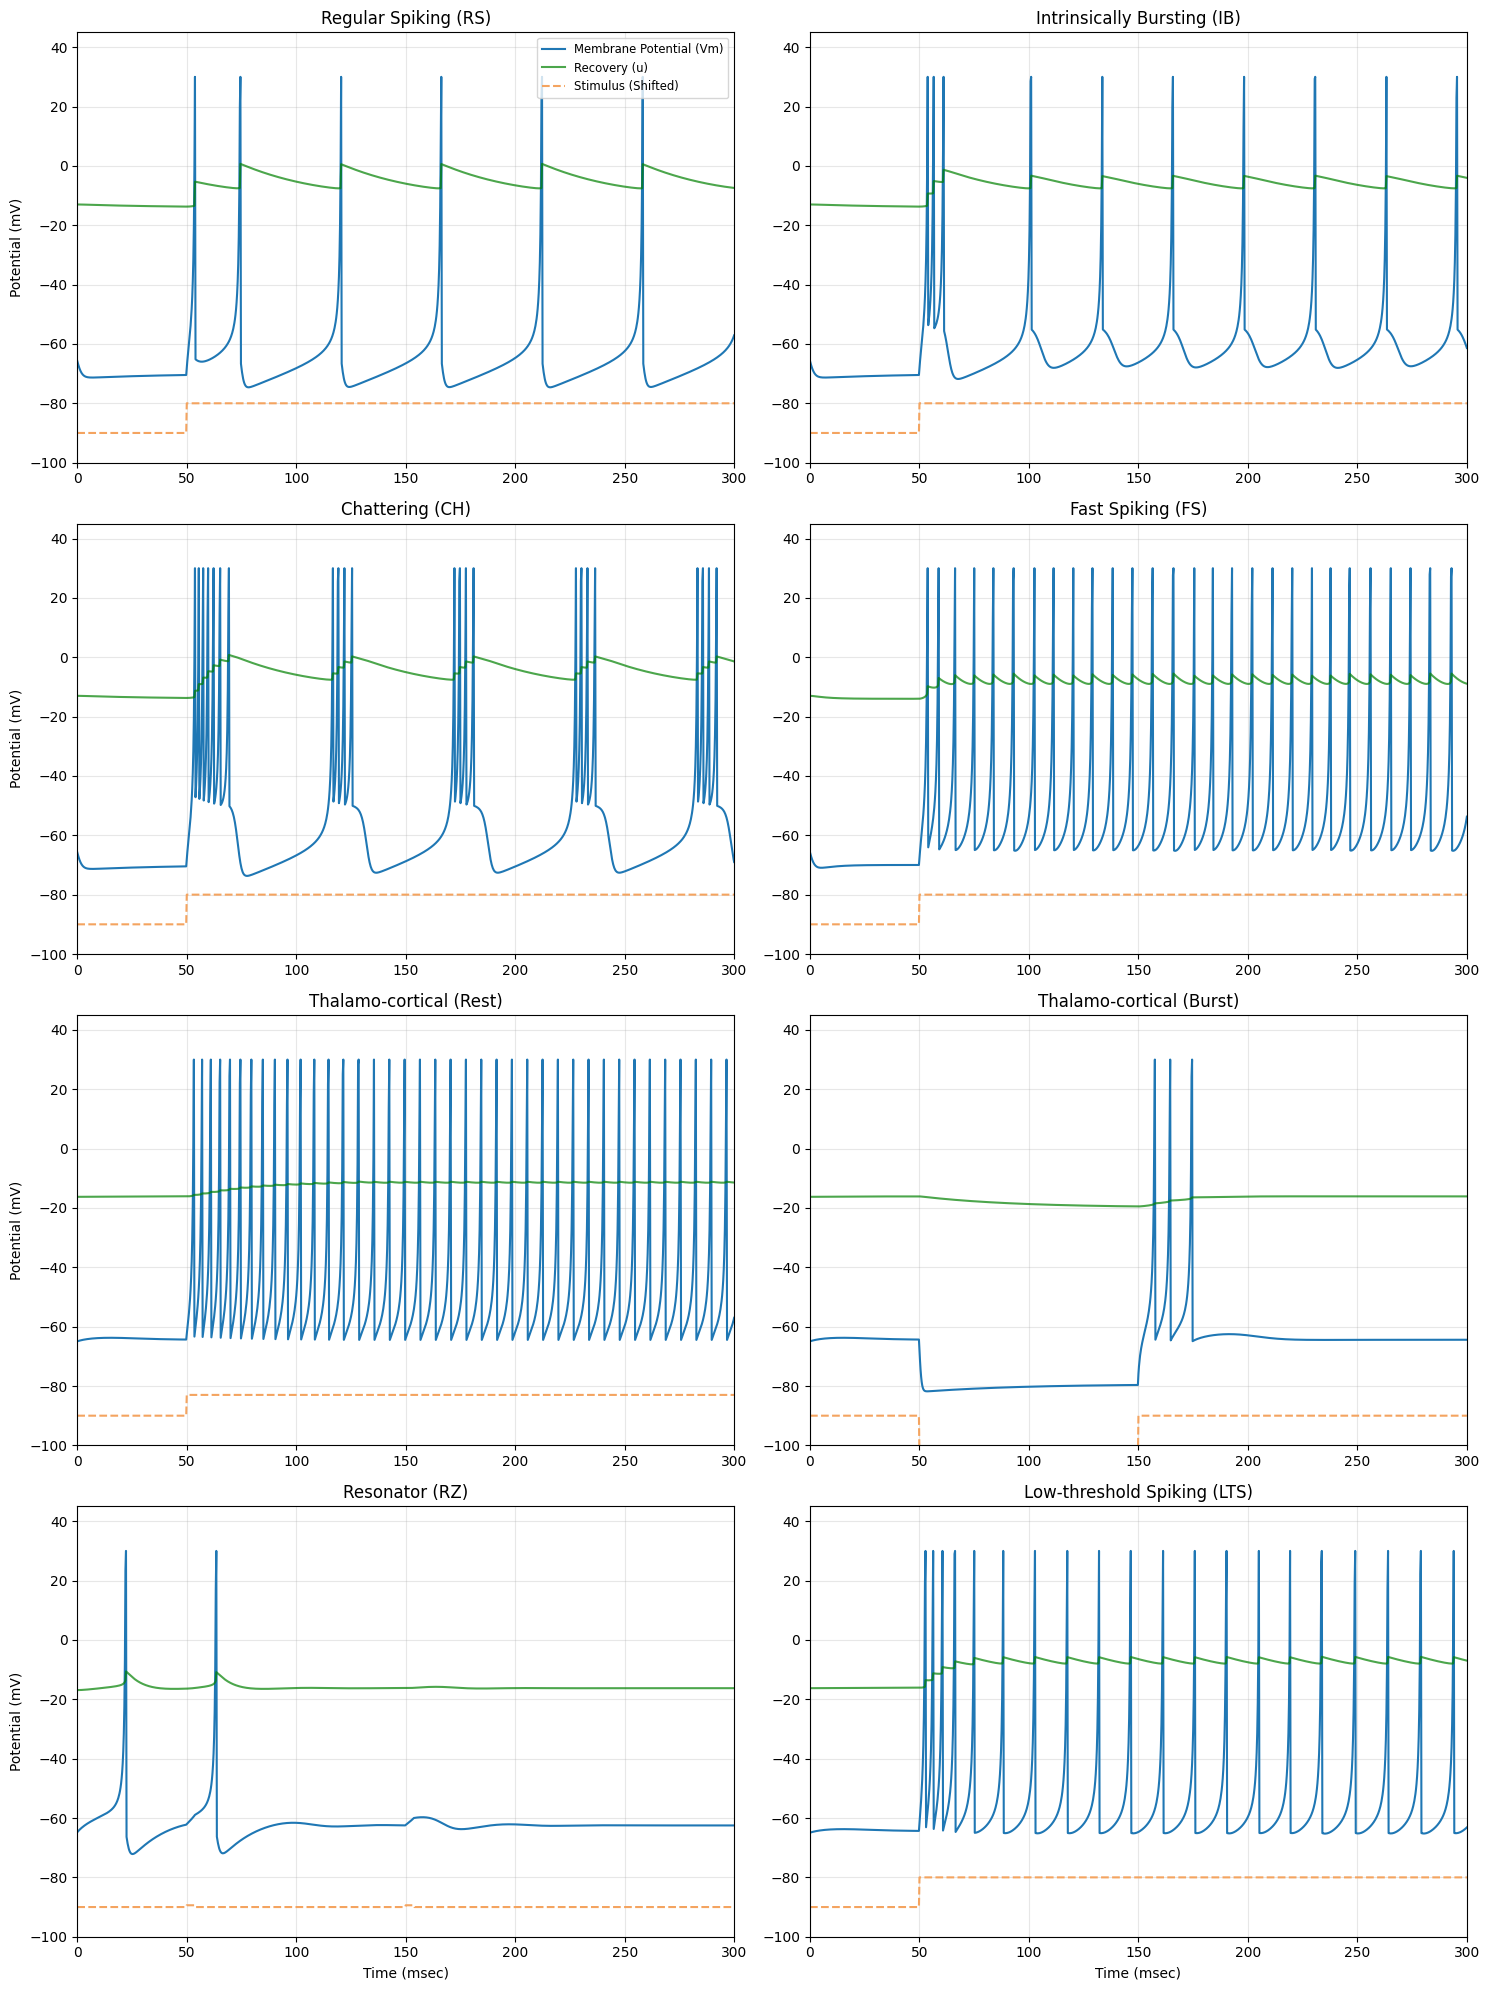

In [24]:
# Simulation parameters
T = 300          # Increased time to allow settling [mSec]
dt = 0.25
time = np.arange(0, T + dt, dt)

# Attributes strictly from Izhikevich 2003
# Format: [a, b, c, d]
params = {
    'Regular Spiking (RS)':        [0.02, 0.2,  -65, 8],
    'Intrinsically Bursting (IB)': [0.02, 0.2,  -55, 4],
    'Chattering (CH)':             [0.02, 0.2,  -50, 2],
    'Fast Spiking (FS)':           [0.1,  0.2,  -65, 2],
    'Thalamo-cortical (Rest)':     [0.02, 0.25, -65, 0.05],
    'Thalamo-cortical (Burst)':    [0.02, 0.25, -65, 0.05],
    'Resonator (RZ)':              [0.1,  0.26, -65, 2],
    'Low-threshold Spiking (LTS)': [0.02, 0.25, -65, 2]
}

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.flatten()

for i, (name, p) in enumerate(params.items()):
    a, b, c, d = p

    # Initialization: Start at resting potential to prevent initial spikes
    v = -65.0 if 'TC' not in name else -63.0
    u = b * v

    v_trace = np.zeros(len(time))
    u_trace = np.zeros(len(time))
    stim = np.zeros(len(time))

    # Stimulus logic
    if name == 'Thalamo-cortical (Burst)':
        # Rebound: Start flat, inhibit, then release at t=150
        stim[int(50/dt):int(150/dt)] = -15
    elif name == 'Resonator (RZ)':
        # Two small pulses to show resonance
        stim[int(50/dt):int(54/dt)] = 0.6
        stim[int(150/dt):int(154/dt)] = 0.6
    elif name == 'Fast Spiking (FS)' or name == 'Low-threshold Spiking (LTS)':
        stim[int(50/dt):] = 10
    else:
        # Standard step for RS, IB, CH, TC-Rest
        stim[int(50/dt):] = 7 if 'Rest' in name else 10

    # Simulation loop
    for t_idx in range(len(time)):
        # Izhikevich Model Equations
        v += dt * (0.04 * v**2 + 5 * v + 140 - u + stim[t_idx])
        u += dt * a * (b * v - u)

        if v >= 30:
            v_trace[t_idx] = 30
            v = c
            u += d
        else:
            v_trace[t_idx] = v
        u_trace[t_idx] = u

    # Plotting
    ax = axs[i]
    ax.plot(time, v_trace, label='Membrane Potential (Vm)', color='C0') # Original Blue
    ax.plot(time, u_trace, label='Recovery (u)', color='green', alpha=0.7)
    ax.plot(time, stim - 90, label='Stimulus (Shifted)', color='sandybrown', linestyle='--')

    ax.set_title(name)
    ax.set_ylim([-100, 45])
    ax.set_xlim([0, T])
    ax.grid(True, alpha=0.3)

    if i >= 6: ax.set_xlabel('Time (msec)')
    if i % 2 == 0: ax.set_ylabel('Potential (mV)')
    if i == 0: ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

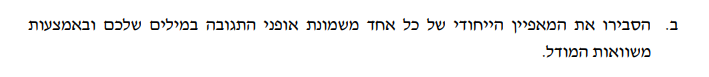

### Izhikevich Neuron Firing Patterns

Here's a brief description of the various neuron firing patterns simulated by the Izhikevich model:

1.  **Regular Spiking (RS):** The most common excitatory neuron. It fires spikes with decreasing frequency (adaptation) when stimulated with a constant current.

2.  **Intrinsically Bursting (IB):** Fires a brief burst of spikes at the beginning of a stimulus, followed by single, regular spikes.

3.  **Chattering (CH):** Fires high-frequency bursts of spikes repeatedly as long as the stimulus is maintained.

4.  **Fast Spiking (FS):** Can fire at very high frequencies without any adaptation (the frequency remains constant throughout the stimulus).

5.  **Thalamo-cortical (TC - Rest):** In its resting state, it remains quiet or fires a few spikes when stimulated. It is characterized by low sensitivity to reset ($d = 0.05$).

6.  **Thalamo-cortical (TC - Burst):** When hyperpolarized (starting at a lower voltage), it exhibits rebound bursts once the inhibition is released.

7.  **Resonator (RZ):** Does not spike in response to standard step inputs. Instead, it oscillates and only spikes when the input frequency matches its resonant frequency.

8.  **Low-threshold Spiking (LTS):** Fires high-frequency spikes with significant adaptation (slowing down quickly) and can exhibit rebound spikes after hyperpolarization.

# Q3

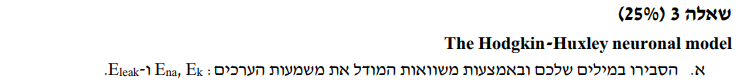

### Explanation of $E_k$, $E_{Na}$, and $E_{leak}$ in the Hodgkin-Huxley Model

In the Hodgkin-Huxley (HH) model, $E_k$, $E_{Na}$, and $E_{leak}$ represent the **reversal potentials** (also known as **equilibrium potentials**) for the potassium, sodium, and leak currents, respectively. These values are crucial because they determine the driving force for each ion species across the neuron's membrane and, consequently, the direction and magnitude of the ionic currents.

#### 1. $E_k$ (Potassium Reversal Potential)

*   **Definition**: $E_k$ is the equilibrium potential for potassium ions ($K^+$). It's the membrane potential at which there is no net movement of $K^+$ ions across the membrane, even if potassium channels are open. This means the electrical force pulling $K^+$ ions in equals the chemical force pushing them out.
*   **Significance**: Typically, the concentration of $K^+$ is much higher inside the neuron than outside. Therefore, $E_k$ is usually negative (hyperpolarized), often around -70 mV to -90 mV. The membrane potential tends to move towards $E_k$ when potassium channels are open, which contributes to repolarization and hyperpolarization during an action potential.

#### 2. $E_{Na}$ (Sodium Reversal Potential)

*   **Definition**: $E_{Na}$ is the equilibrium potential for sodium ions ($Na^+$). It's the membrane potential at which there is no net movement of $Na^+$ ions across the membrane.
*   **Significance**: The concentration of $Na^+$ is much higher outside the neuron than inside. Consequently, $E_{Na}$ is typically positive (depolarized), often around +50 mV to +60 mV. When voltage-gated sodium channels open rapidly during an action potential, the membrane potential depolarizes and rushes towards $E_{Na}$, causing the rising phase (depolarization) of the spike.

#### 3. $E_{leak}$ (Leak Reversal Potential)

*   **Definition**: $E_{leak}$ is the reversal potential for the **leak current**. This current represents the flow of ions through non-gated channels, which are always (or almost always) open. It's often a combination of several ion types, but primarily reflects the resting permeability of the membrane to ions like potassium and chloride.
*   **Significance**: The leak current is responsible for setting the **resting membrane potential** ($V_{	ext{rest}}$) of the neuron when no other active currents are flowing. Because the neuron's membrane is typically most permeable to potassium at rest, $E_{leak}$ is usually close to $E_k$, and thus also negative (hyperpolarized), often around -60 mV to -70 mV. It acts as a stabilizing force, pulling the membrane potential back towards rest when it deviates.

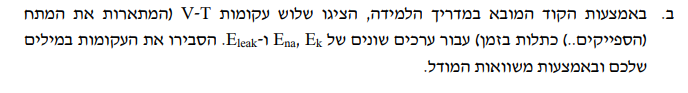

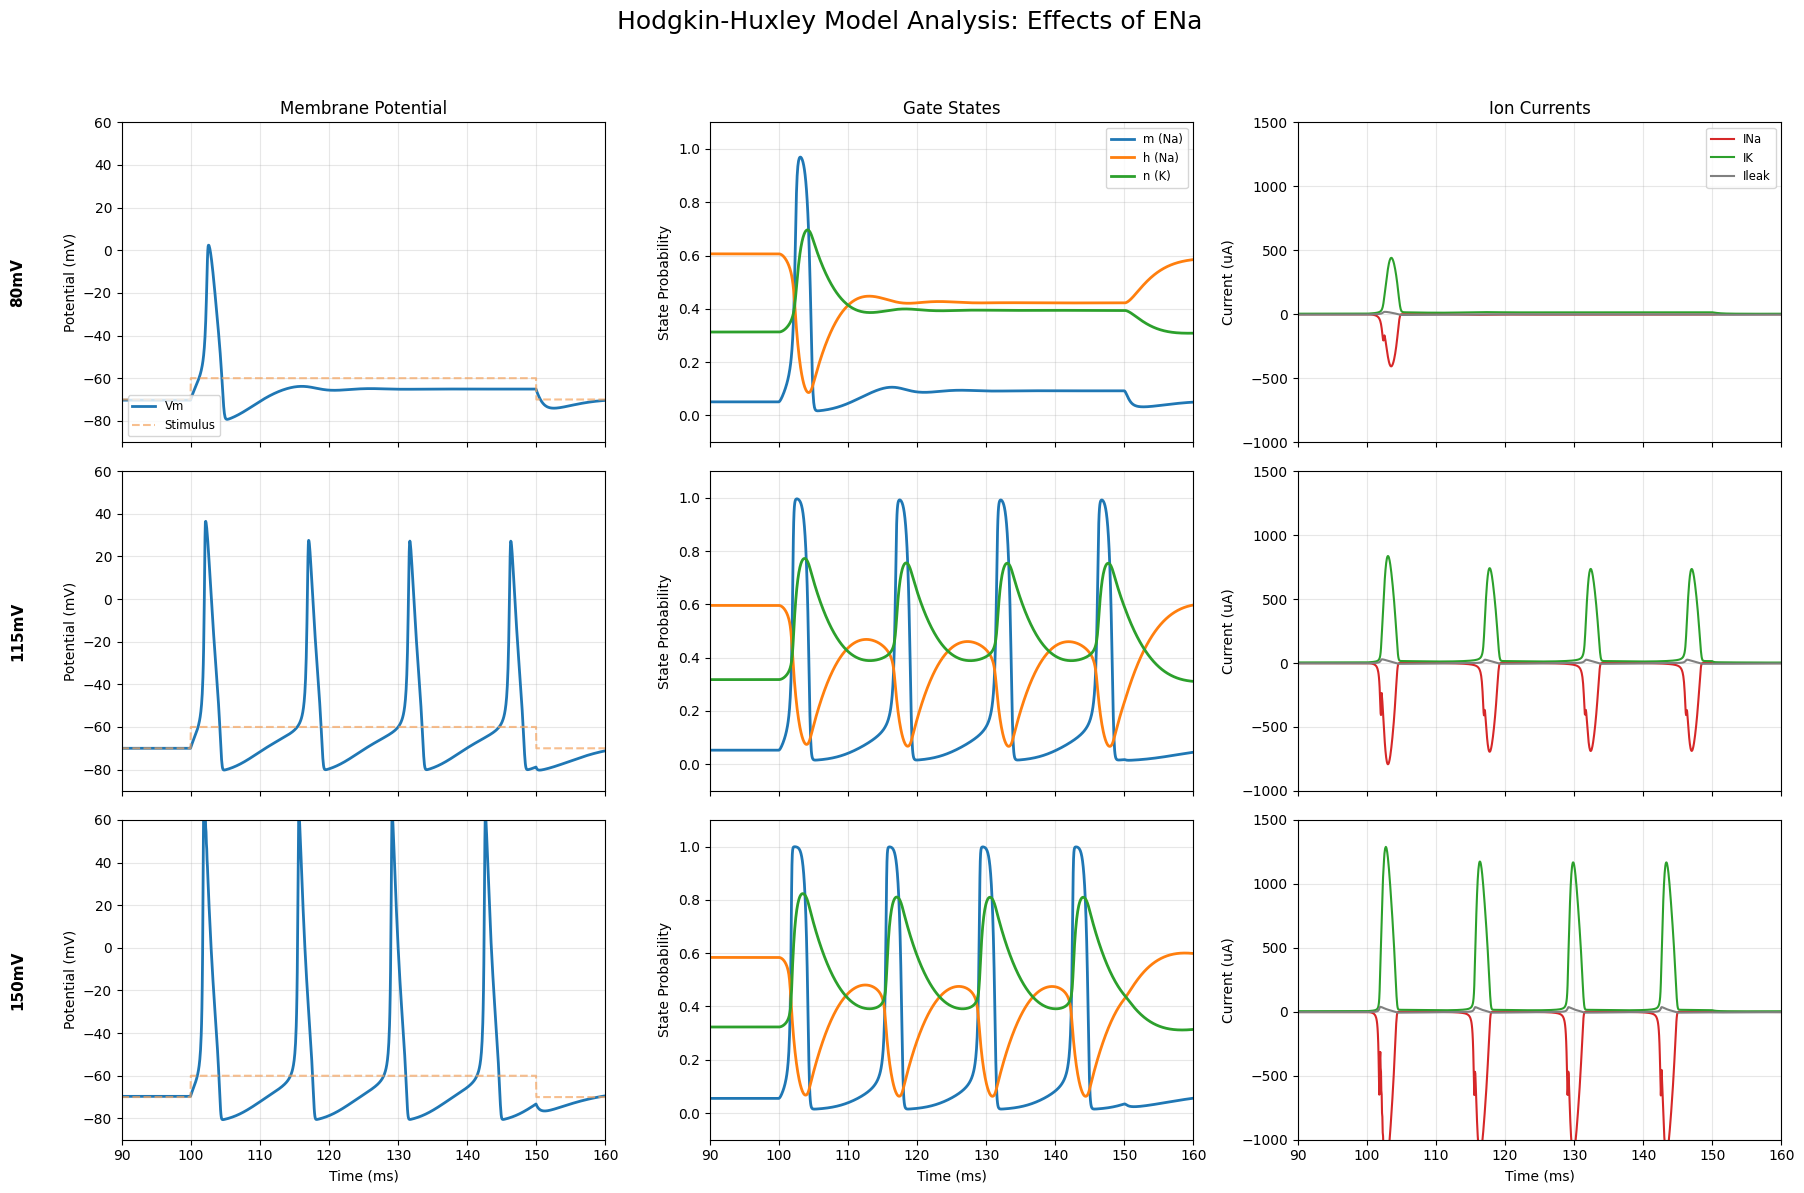

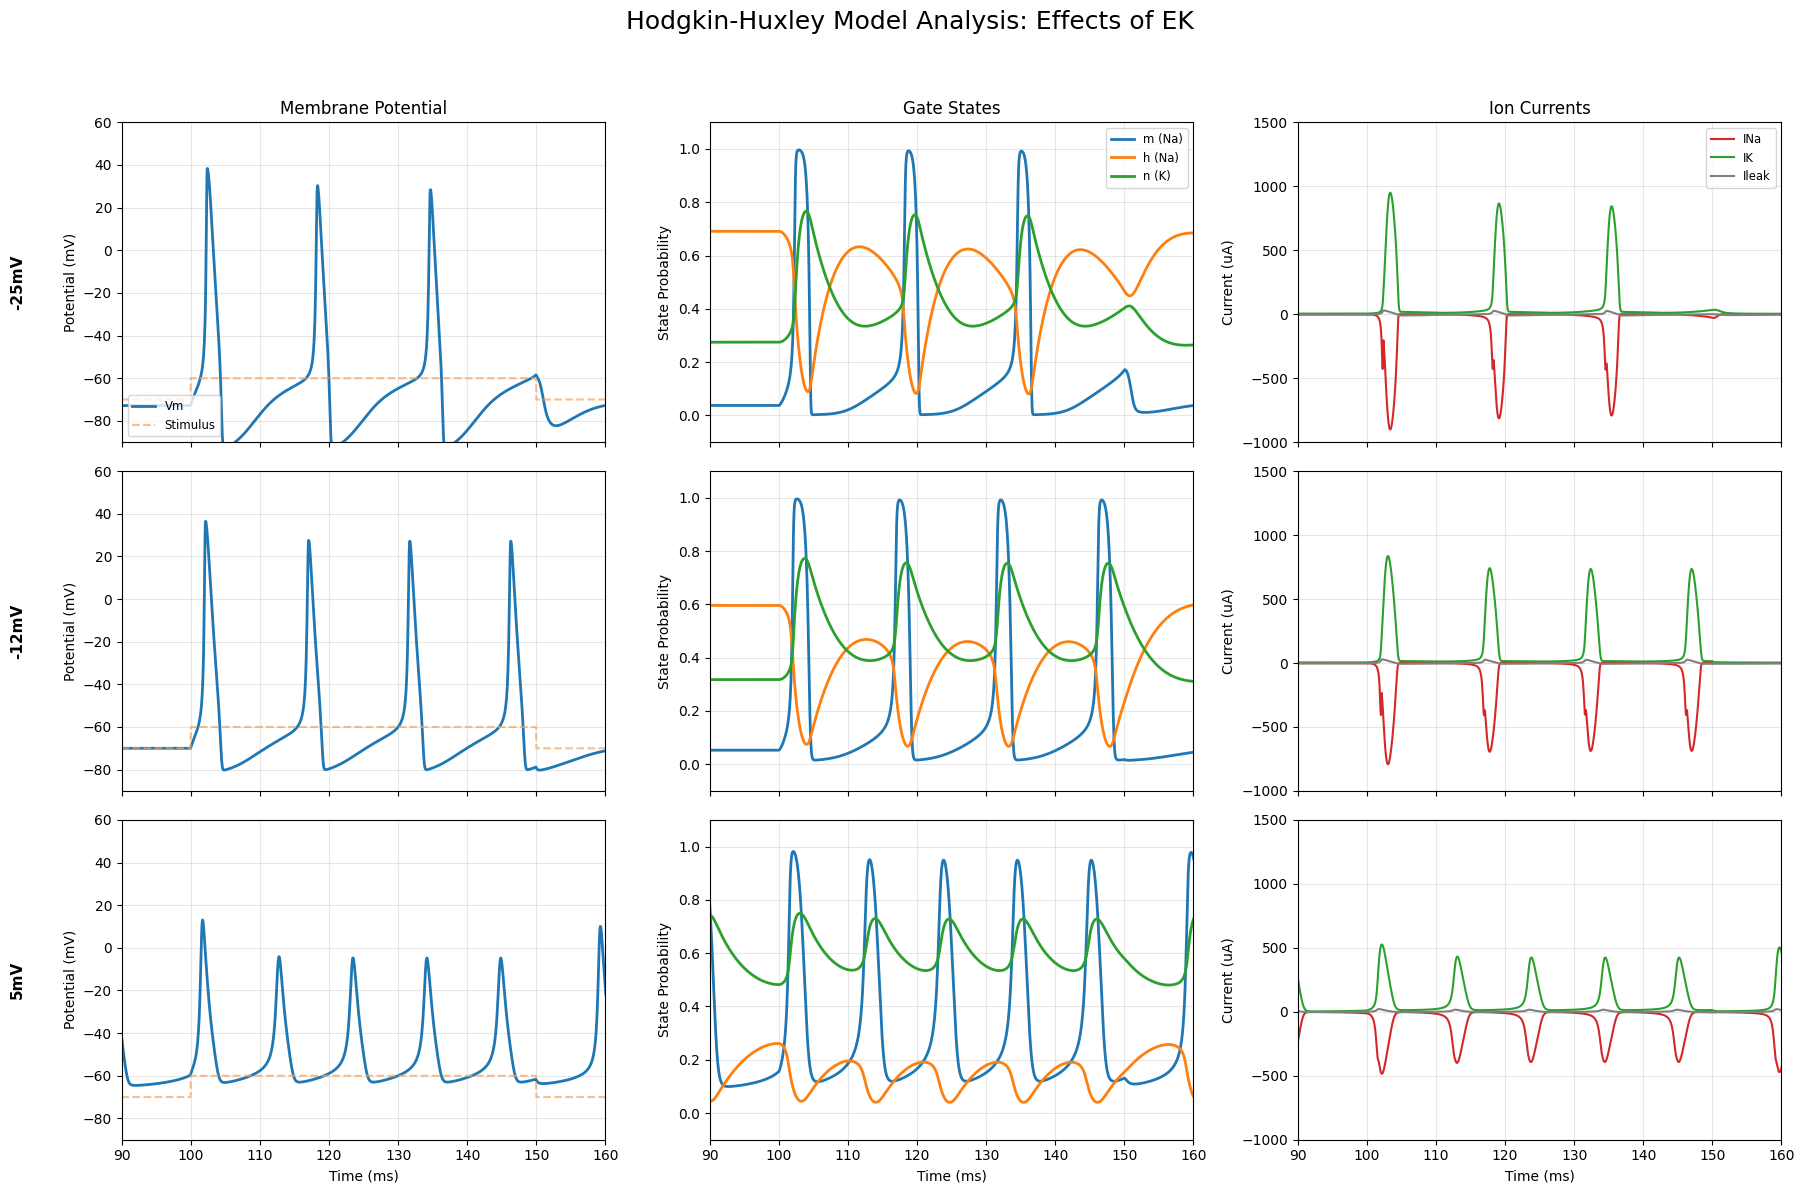

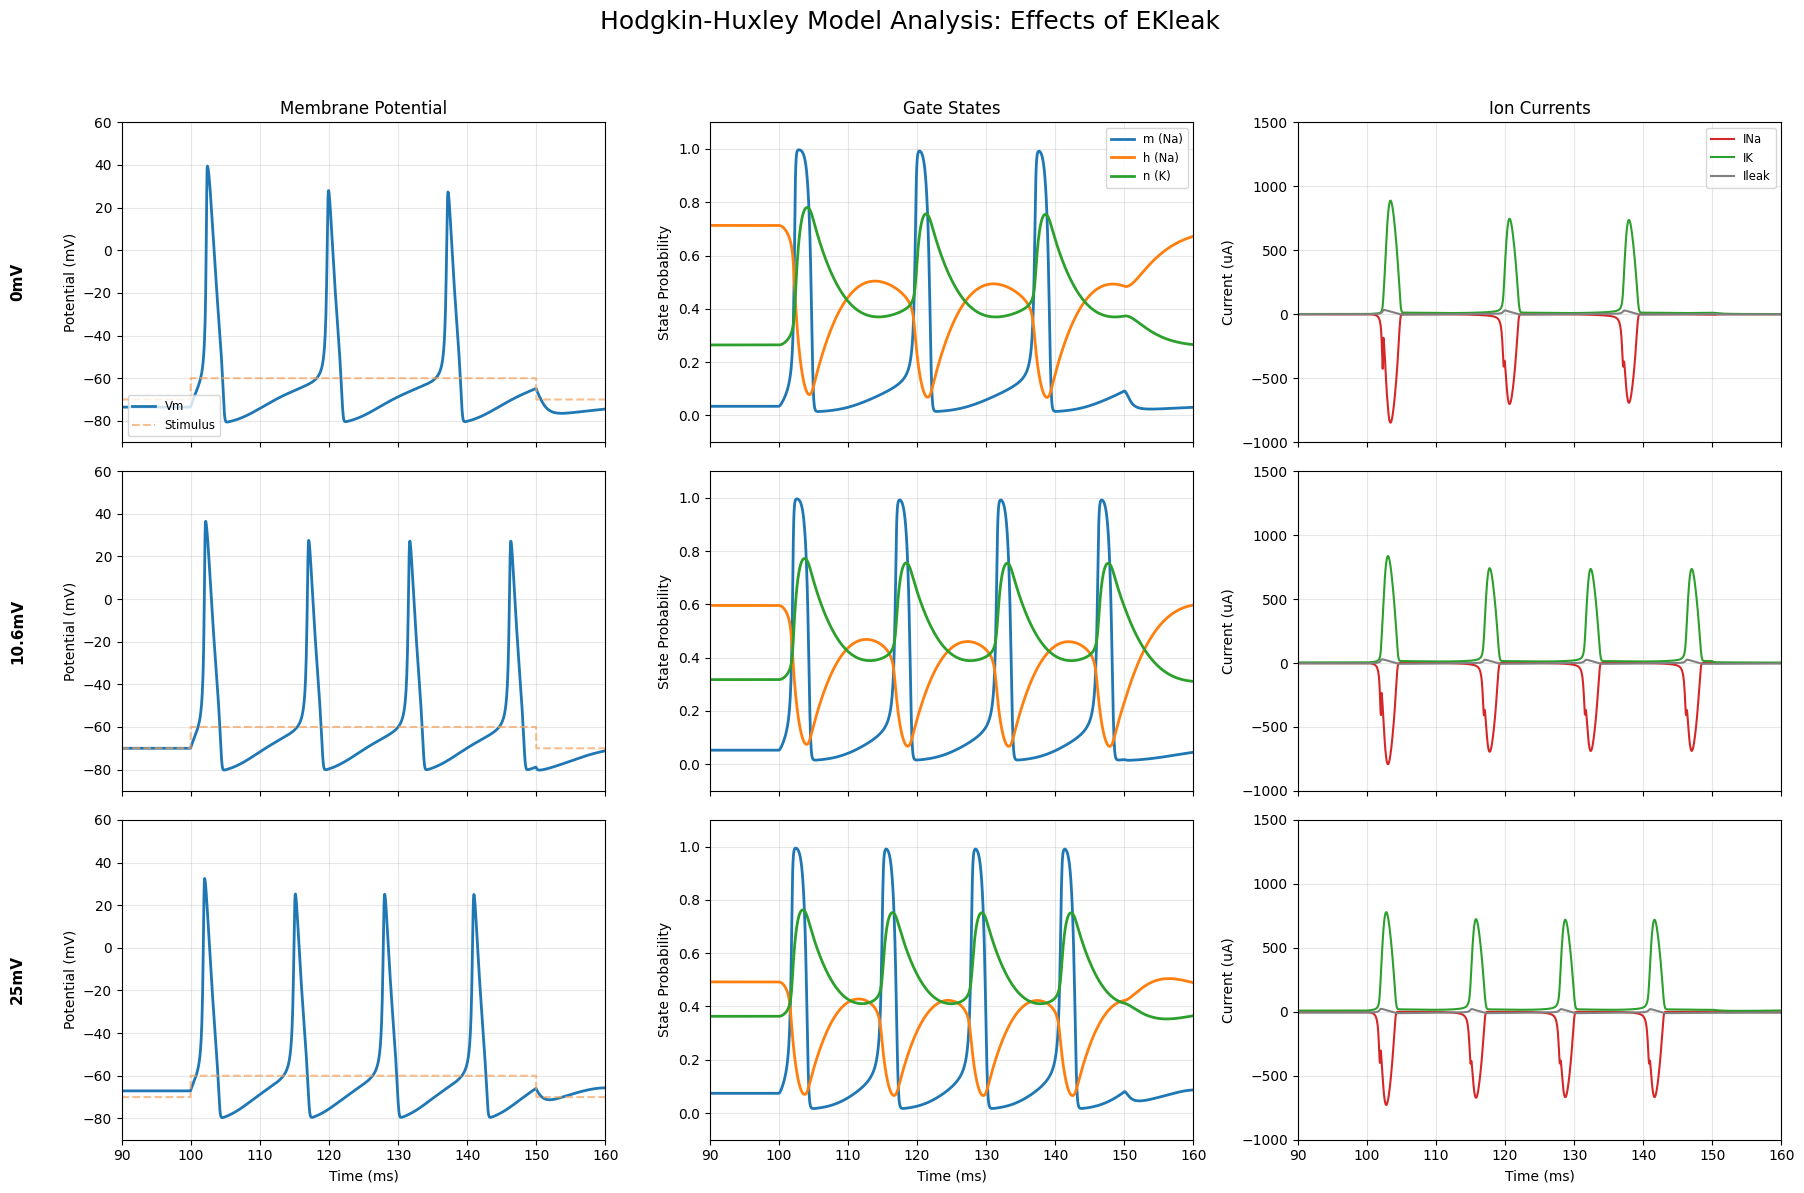

In [23]:
class HHModel:
    class Gate:
        alpha, beta, state = 0, 0, 0
        def update(self, deltaTms):
            alphaState = self.alpha * (1-self.state)
            betaState = self.beta * self.state
            self.state += deltaTms * (alphaState - betaState)
        def setInfiniteState(self):
            self.state = self.alpha / (self.alpha + self.beta)

    gNa, gK, gKleak = 120, 36, 0.3
    Cm = 1

    def __init__(self, ENa=115, EK=-12, EKleak=10.6, startingVoltage=0):
        self.ENa, self.EK, self.EKleak = ENa, EK, EKleak
        self.Vm = startingVoltage
        self.m, self.n, self.h = self.Gate(), self.Gate(), self.Gate()
        self.UpdateGateTimeConstants(startingVoltage)
        self.m.setInfiniteState()
        self.n.setInfiniteState()
        self.h.setInfiniteState()
        self.INa = self.IK = self.IKleak = self.Isum = 0

    def UpdateGateTimeConstants(self, Vm):
        self.n.alpha = .01 * ((10-Vm) / (np.exp((10-Vm)/10)-1))
        self.n.beta = .125*np.exp(-Vm/80)
        self.m.alpha = .1*((25-Vm) / (np.exp((25-Vm)/10)-1))
        self.m.beta = 4*np.exp(-Vm/18)
        self.h.alpha = .07*np.exp(-Vm/20)
        self.h.beta = 1/(np.exp((30-Vm)/10)+1)

    def UpdateCellVoltage(self, stimulusCurrent, deltaTms):
        self.INa = np.power(self.m.state, 3) * self.gNa * self.h.state * (self.Vm - self.ENa)
        self.IK = np.power(self.n.state, 4) * self.gK * (self.Vm - self.EK)
        self.IKleak = self.gKleak * (self.Vm - self.EKleak)
        self.Isum = stimulusCurrent - self.INa - self.IK - self.IKleak
        self.Vm += deltaTms * self.Isum / self.Cm

    def UpdateGateStates(self, deltaTms):
        self.n.update(deltaTms)
        self.m.update(deltaTms)
        self.h.update(deltaTms)

    def Iterate(self, stimulusCurrent=0, deltaTms=0.05):
        self.UpdateGateTimeConstants(self.Vm)
        self.UpdateCellVoltage(stimulusCurrent, deltaTms)
        self.UpdateGateStates(deltaTms)

# --- Simulation Parameters ---
pointCount = 5000
dt = 0.05
times = np.arange(pointCount) * dt
stim = np.zeros(pointCount)
stim[2000:3000] = 10

test_params = {
    "ENa": [80, 115, 150],
    "EK": [-25, -12, 5],
    "EKleak": [0, 10.6, 25]
}

defaults = {"ENa": 115, "EK": -12, "EKleak": 10.6}

# Constants for easy access to subplots
PARAM_NAMES = list(test_params.keys())
NUM_VALUES_PER_PARAM = 3                # Each ENa, EK, EKleak has 3 values
PLOTS_PER_VALUE = 3                     # Vm, Gates, Currents

# Loop through each parameter type (ENa, EK, EKleak)
for param_name_idx, (param_name, values) in enumerate(test_params.items()):
    fig, axs = plt.subplots(NUM_VALUES_PER_PARAM, PLOTS_PER_VALUE, figsize=(18, 12), sharex='col') # Share x-axis across columns, no shared y-axis
    fig.suptitle(f'Hodgkin-Huxley Model Analysis: Effects of {param_name}', fontsize=18, y=1.02) # Main title for each figure

    # Set column titles on the first row of each new figure
    axs[0, 0].set_title('Membrane Potential', fontsize=12)
    axs[0, 1].set_title('Gate States', fontsize=12)
    axs[0, 2].set_title('Ion Currents', fontsize=12)

    for value_idx, val in enumerate(values):
        current_config = defaults.copy()
        current_config[param_name] = val

        # Run Simulation
        hh = HHModel(**current_config)
        Vm, n, m, h = np.zeros(pointCount), np.zeros(pointCount), np.zeros(pointCount), np.zeros(pointCount)
        INa, IK, IKleak, Isum = np.zeros(pointCount), np.zeros(pointCount), np.zeros(pointCount), np.zeros(pointCount)

        for i in range(pointCount):
            hh.Iterate(stimulusCurrent=stim[i], deltaTms=dt)
            Vm[i], n[i], m[i], h[i] = hh.Vm, hh.n.state, hh.m.state, hh.h.state
            INa[i], IK[i], IKleak[i], Isum[i] = hh.INa, hh.IK, hh.IKleak, hh.Isum

        # Plot Vm
        ax_vm = axs[value_idx, 0]
        ax_vm.plot(times, Vm - 70, label='Vm', color='tab:blue', linewidth=2)
        ax_vm.plot(times, stim - 70, label='Stimulus', color='sandybrown', linestyle='--', alpha=0.7)
        ax_vm.set_ylim([-90, 60])
        ax_vm.grid(True, alpha=0.3)
        # Add parameter value label to the left of the row
        ax_vm.text(-0.2, 0.5, f'{val}mV', transform=ax_vm.transAxes, rotation=90, va='center', ha='right', fontsize=11, weight='bold')
        if value_idx == 0: # Legend only for the first Vm plot in each figure
            ax_vm.legend(loc='lower left', fontsize='small')
        if value_idx == NUM_VALUES_PER_PARAM - 1: # X-label only for bottom row of each figure
            ax_vm.set_xlabel('Time (ms)')
        ax_vm.set_ylabel('Potential (mV)') # Y-label for Vm column

        # Plot Gate States
        ax_gates = axs[value_idx, 1]
        ax_gates.plot(times, m, label='m (Na)', linewidth=2)
        ax_gates.plot(times, h, label='h (Na)', linewidth=2)
        ax_gates.plot(times, n, label='n (K)', linewidth=2)
        ax_gates.set_ylim([-0.1, 1.1])
        ax_gates.grid(True, alpha=0.3)
        if value_idx == 0: # Legend only for the first Gate States plot in each figure
            ax_gates.legend(loc='upper right', fontsize='small')
        if value_idx == NUM_VALUES_PER_PARAM - 1: # X-label only for bottom row of each figure
            ax_gates.set_xlabel('Time (ms)')
        ax_gates.set_ylabel('State Probability') # Y-label for Gate States column

        # Plot Ion Currents
        ax_currents = axs[value_idx, 2]
        ax_currents.plot(times, INa, label='INa', color='tab:red')
        ax_currents.plot(times, IK, label='IK', color='tab:green')
        ax_currents.plot(times, IKleak, label='Ileak', color='gray')
        ax_currents.set_ylim([-1000, 1500])
        ax_currents.grid(True, alpha=0.3)
        if value_idx == 0: # Legend only for the first Ion Currents plot in each figure
            ax_currents.legend(loc='upper right', fontsize='small')
        if value_idx == NUM_VALUES_PER_PARAM - 1: # X-label only for bottom row of each figure
            ax_currents.set_xlabel('Time (ms)')
        ax_currents.set_ylabel('Current (uA)') # Y-label for Ion Currents column

    # Adjust x-axis limits for all subplots in the current figure
    for row_axs in axs:
        for ax in row_axs:
            ax.set_xlim([90, 160])

    plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Adjust layout to prevent suptitle overlap
    plt.show()

### Explanation of Hodgkin-Huxley Model Plots: Effects of $E_{Na}$, $E_K$, and $E_{leak}$

The Hodgkin-Huxley model describes the ionic mechanisms underlying action potentials. The total membrane current ($I_{ion}$) is the sum of sodium ($I_{Na}$), potassium ($I_K$), and leak ($I_{leak}$) currents. The change in membrane potential ($V_m$) over time is given by:

$\frac{dV_m}{dt} = \frac{1}{C_m} (I_{stim} - I_{Na} - I_K - I_{leak})$

Each ionic current is calculated as:
$I_{ion} = g_{ion} (V_m - E_{ion})$

Where $g_{ion}$ is the conductance and $E_{ion}$ is the reversal potential. The plots above demonstrate the impact of varying these reversal potentials:

#### 1. Effect of varying $E_{Na}$ (Sodium Reversal Potential)

*   **Equation Impact**: $I_{Na} = g_{Na} m^3 h (V_m - E_{Na})$. A higher $E_{Na}$ increases the driving force for sodium ions when $V_m$ is below $E_{Na}$, leading to a larger inward sodium current during depolarization.
*   **Plot Observations**:
    *   **Membrane Potential ($V_m$)**: Increasing $E_{Na}$ (e.g., from 80 mV to 150 mV, relative to a fixed $V_{rest}$ of -70 mV) allows the membrane potential to peak at a more positive value during an action potential. This is because the influx of $Na^+$ ions drives $V_m$ closer to $E_{Na}$. Lowering $E_{Na}$ results in a lower peak $V_m$.
    *   **$I_{Na}$ Current**: The peak amplitude of the inward (negative) sodium current increases with higher $E_{Na}$, as the driving force $ (V_m - E_{Na}) $ becomes larger (more negative if $V_m < E_{Na}$), pulling more $Na^+$ into the cell.

#### 2. Effect of varying $E_K$ (Potassium Reversal Potential)

*   **Equation Impact**: $I_K = g_K n^4 (V_m - E_K)$. A more negative $E_K$ increases the driving force for potassium ions when $V_m$ is above $E_K$, leading to a larger outward potassium current during repolarization.
*   **Plot Observations**:
    *   **Membrane Potential ($V_m$)**: Increasing $E_K$ (e.g., from -25 mV to 5 mV) makes the cell repolarize faster and hyperpolarize less (or not at all) after a spike. A more negative $E_K$ results in a stronger outward $K^+$ current, leading to a more pronounced after-hyperpolarization following a spike.
    *   **$I_K$ Current**: The peak amplitude of the outward (positive) potassium current changes with $E_K$. A more negative $E_K$ increases the outward current, pulling $V_m$ further from threshold.

#### 3. Effect of varying $E_{leak}$ (Leak Reversal Potential)

*   **Equation Impact**: $I_{leak} = g_{leak} (V_m - E_{leak})$. This current contributes significantly to setting the resting membrane potential.
*   **Plot Observations**:
    *   **Membrane Potential ($V_m$)**: Changing $E_{leak}$ primarily shifts the resting membrane potential. If $E_{leak}$ is made more positive (e.g., from 0 mV to 25 mV), the resting potential of the neuron becomes less negative, making it easier to reach the threshold for an action potential. If $E_{leak}$ is more negative, the resting potential becomes more hyperpolarized.
    *   **$I_{leak}$ Current**: The magnitude and direction of the leak current change to bring $V_m$ closer to $E_{leak}$. A more positive $E_{leak}$ will result in a more positive resting $V_m$ and potentially affect the overall excitability of the neuron by reducing the current needed to reach threshold.

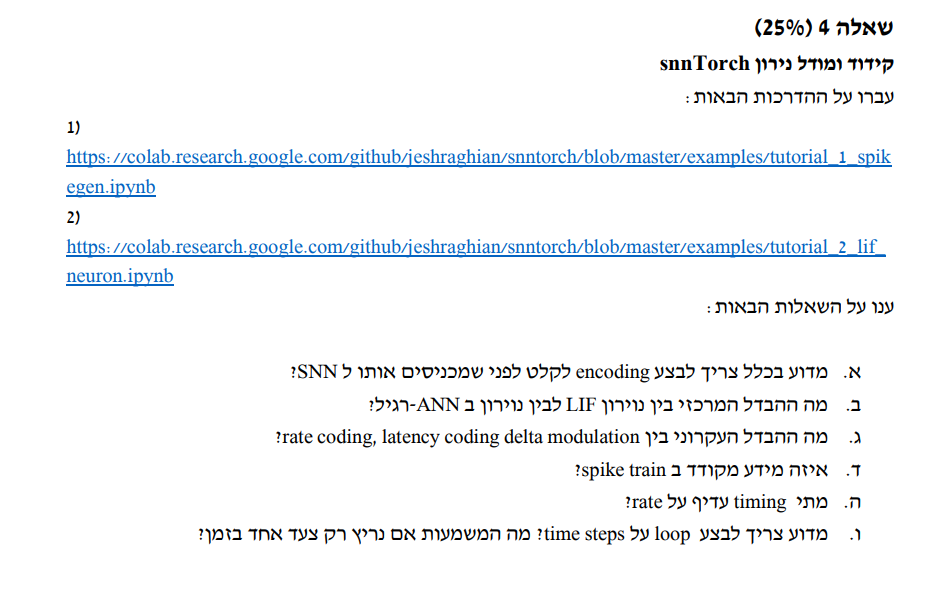


1.  **Why is encoding necessary before feeding input into an SNN?**
    Spiking Neural Networks (SNNs) process information using discrete binary events called "spikes" (0 or 1) across time. Most common datasets, such as MNIST, consist of static, high-precision continuous values. Encoding is the process of converting these static values into spike trains so the network can leverage temporal dynamics, sparsity, and energy efficiency.

2.  **What is the main difference between an LIF neuron and a standard ANN neuron?**
    *   **Standard ANN Neuron**: It calculates a weighted sum of inputs and passes it through a static activation function; it lacks a concept of time or internal memory.
    *   **LIF Neuron**: It introduces a temporal dimension. It integrates weighted inputs into a membrane potential while "leaking" that potential back to rest over time. A spike is only generated when this accumulated potential crosses a specific threshold.

3.  **What is the fundamental difference between Rate Coding, Latency Coding, and Delta Modulation?**
    *   **Rate Coding**: Information is represented by the frequency of spikes; higher input values lead to more spikes within a specific time window.
    *   **Latency Coding**: Information is represented by the timing of the first spike; higher values cause the neuron to fire earlier in the simulation.
    *   **Delta Modulation**: Information is represented by the change in input; a spike is only generated when the input value fluctuates significantly relative to the previous step.

4.  **What information is encoded in a spike train?**
    In a spike train, the individual spike itself carries no information other than being a "1" or "0". The actual data is encoded in the timing of those spikes or the frequency (rate) at which they occur.

5.  **When is timing-based coding preferable over rate-based coding?**
    Timing-based coding (like Latency) is often more efficient for fast processing and energy conservation. It allows a single spike to convey a value immediately, whereas rate coding requires waiting for a window of time to pass to calculate the spike frequency.

6.  **Why is it necessary to loop over time steps? What happens if we run only one step?**
    SNNs are inherently temporal; a neuron's current state (membrane potential) depends on its state in the previous time step. The loop is necessary to simulate the evolution of this state over a duration. If you run only one time step, the system cannot accumulate information or detect patterns over time, causing it to lose its "memory" and function like a standard memoryless ANN.